<a href="https://colab.research.google.com/github/WinstonNji/Content-Management-System/blob/main/Recurrent_Neural_Network_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# From Scratch Implementation

In [ ]:
import numpy as np

# dataset — predict next value in a linear trend with noise
np.random.seed(0)
series = np.arange(50) * 0.1 + 0.3 * np.random.randn(50)

seq_len = 4
X, Y = [], []
for i in range(len(series) - seq_len):
    X.append(series[i : i + seq_len])
    Y.append(series[i + seq_len])

X = np.array(X)  # (46, 4)
Y = np.array(Y)  # (46,)

# hyperparams
input_size  = 1
hidden_size = 16
output_size = 1
lr          = 0.001
epochs      = 500
loss_tracker = []

In [ ]:
Wxh = np.random.randn(hidden_size,input_size) * 0.01
Whh = np.random.randn(hidden_size,hidden_size) * 0.01
Why = np.random.randn(output_size,hidden_size) * 0.01

bh = np.zeros((hidden_size,1))
by = np.zeros((output_size,1))

In [ ]:
for epoch in range(epochs):
  loss_per_epoch = 0

  for s in range(len(X)):
    h = np.zeros((hidden_size,1))
    hs = {0:h.copy()}

    for t in range(seq_len):

      # ######### FORWARD PASS #############33

      x_t = X[s,t].reshape(input_size,1)

      h = np.tanh(Wxh @ x_t + Whh @ h + bh)
      hs[t + 1] = h.copy()

    y_pred = Why @ h + by
    y_target = Y[s].reshape(output_size,1)

    loss = 0.5 * (y_pred - y_target) ** 2
    loss_per_epoch += loss.item()



    # ############ BACKPROPAGATION ############

    dWxh = np.zeros_like(Wxh)
    dWhh =  np.zeros_like(Whh)
    dWhy =  np.zeros_like(Why)
    dby = np.zeros_like(by)
    dbh = np.zeros_like(bh)

    dh_next = np.zeros((hidden_size,1))

    dy = y_pred - y_target
    dWhy += dy @ h.T
    dby += dy

    for t in reversed(range(1,seq_len+1)):
      x_t = X[s,t-1].reshape(input_size,1)

      dh  = (Why.T @ dy + dh_next) * (1 - hs[t] ** 2)

      dWhh += dh @ hs[t-1].T
      dWxh += dh @ x_t.T

      dbh += dh

      dh_next = Whh.T @ dh

    for grad in [dWxh, dWhh, dWhy, dbh, dby]:
      np.clip(grad, -1, 1, out=grad)

    Wxh -= lr * dWxh
    Whh -= lr * dWhh
    Why -= lr * dWhy
    bh -= lr * dbh
    by -= lr * dby

  loss_tracker.append( loss_per_epoch / len(X))

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss_per_epoch}")


Epoch: 0, Loss: 196.1900413644218
Epoch: 10, Loss: 17.434656704710825
Epoch: 20, Loss: 10.421391274373352
Epoch: 30, Loss: 7.03527986380864
Epoch: 40, Loss: 5.648134161236447
Epoch: 50, Loss: 5.145601269837778
Epoch: 60, Loss: 4.992923755016301
Epoch: 70, Loss: 4.95470076221429
Epoch: 80, Loss: 4.945099359632101
Epoch: 90, Loss: 4.938377548097206
Epoch: 100, Loss: 4.928817271833429
Epoch: 110, Loss: 4.916168127219437
Epoch: 120, Loss: 4.9010705002059645
Epoch: 130, Loss: 4.88409728628802
Epoch: 140, Loss: 4.8656900445501305
Epoch: 150, Loss: 4.846062456938608
Epoch: 160, Loss: 4.825304506848966
Epoch: 170, Loss: 4.803448076308603
Epoch: 180, Loss: 4.780547413221057
Epoch: 190, Loss: 4.756631006838268
Epoch: 200, Loss: 4.7315489226805365
Epoch: 210, Loss: 4.705134356839932
Epoch: 220, Loss: 4.677252492616636
Epoch: 230, Loss: 4.647842363994075
Epoch: 240, Loss: 4.6170854946657665
Epoch: 250, Loss: 4.585283470866411
Epoch: 260, Loss: 4.552539590339398
Epoch: 270, Loss: 4.518997508906472


In [ ]:
pred = []
actual = []

for i in range(len(X)):
    h = np.zeros((hidden_size,1))
    hs = {0:h.copy()}

    for t in range(seq_len):
      # ---------- FORWARD PASSS ----------
      x_t = X[i,t].reshape(1,1)

      h = np.tanh(Wxh @ x_t + Whh @ h + bh)
      hs[t+1] = h.copy()

    # --------- Compute loss ------------

    y_pred = Why @ h + by
    pred.append(y_pred.item())

    y_target = Y[i].reshape(1,1)
    actual.append(y_target.item())




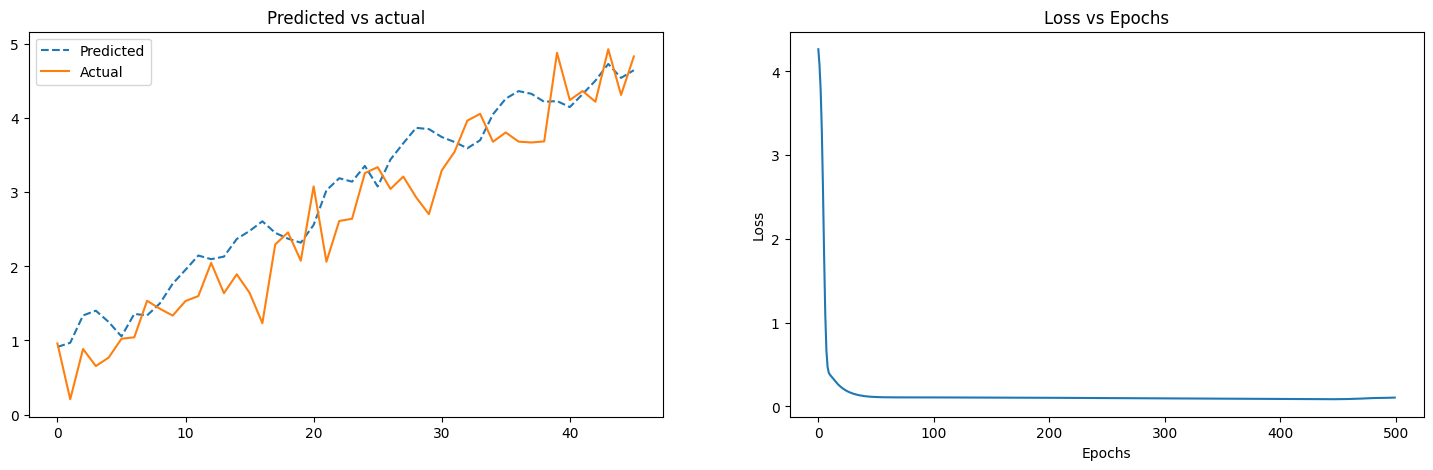

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(18,5))

ax[0].plot(pred, label='Predicted', linestyle='--')
ax[0].plot(actual, label='Actual')
ax[0].set_title('Predicted vs actual')
ax[0].legend()

ax[1].plot(loss_tracker)
ax[1].set_title('Loss vs Epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')


plt.show()

# Tensorflow Implementation

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

In [ ]:
# TF expects (batch, timesteps, features)

X = X.reshape(-1,seq_len,1)

In [ ]:
model = Sequential([
    layers.SimpleRNN(hidden_size, input_shape=(seq_len,input_size)),
    layers.Dense(output_size)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
history = model.fit(
    X,
    Y,
    epochs = 150,
    validation_split =0.2,
    verbose = 1
)

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - loss: 2.8955 - mae: 1.5196 - val_loss: 8.5356 - val_mae: 2.8888
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2.5365 - mae: 1.4125 - val_loss: 7.8367 - val_mae: 2.7648
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2.2094 - mae: 1.3021 - val_loss: 7.1864 - val_mae: 2.6443
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 1.9100 - mae: 1.1950 - val_loss: 6.5884 - val_mae: 2.5283
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.6591 - mae: 1.0921 - val_loss: 6.0619 - val_mae: 2.4216
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.4248 - mae: 0.9898 - val_loss: 5.5982 - val_mae: 2.3235
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 1.2409 - mae: 0.9026 - val_loss: 5.1848 - val_mae: 2.2324
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1.0695 - mae: 0.8212 - val_loss: 4.8091 - val_mae: 2.1463
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.9372 - mae:

In [ ]:
pred = model.predict(X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


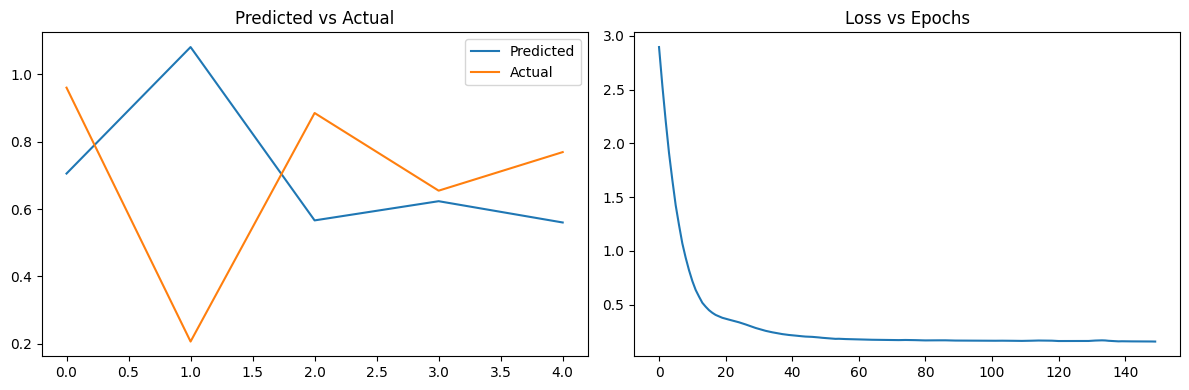

In [ ]:

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].plot(pred[0:5].flatten(), label='Predicted')
axes[0].plot(Y[0:5], label = 'Actual')
axes[0].legend()
axes[0].set_title('Predicted vs Actual')


axes[1].plot(history.history['loss'])
axes[1].set_title('Loss vs Epochs')

plt.tight_layout()
plt.show()